# Principle Component Analysis

Generating 1a

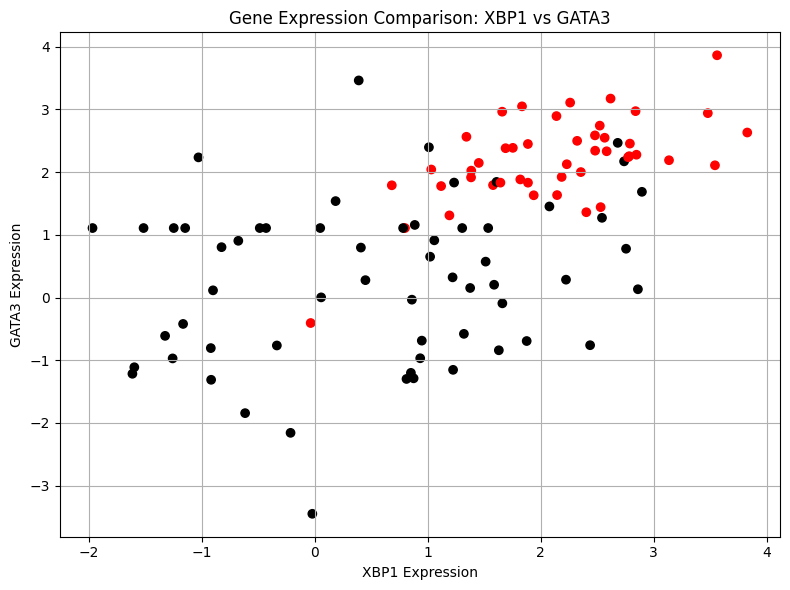

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import gzip
import seaborn as sns

# Step 1: Load ER Status Labels
# These indicate whether each sample is estrogen receptor positive (1) or negative (0)
with open('class.tsv', 'r') as label_file:
    er_status = pd.read_csv(label_file, sep='\t', header=None).squeeze().values

# Step 2: Load Gene Annotation Table
# Maps gene numeric IDs to readable gene symbols like "GATA3"
with gzip.open('columns.tsv.gz', 'rt') as annotation_file:
    valid_lines = [line for line in annotation_file if not line.startswith('#')]
gene_map_df = pd.read_csv(StringIO(''.join(valid_lines)), sep='\t')

# Step 3: Load Gene Expression Matrix
# Each row is a sample, and each column is a gene (by numeric ID)
with gzip.open('filtered.tsv.gz', 'rt') as expr_file:
    expr_data_df = pd.read_csv(expr_file, sep='\t', index_col=0)

# Ensure all gene ID columns are clean strings
expr_data_df.columns = expr_data_df.columns.astype(str).str.strip()

# Step 4: Locate Gene Identifiers of Interest
# We're focusing on two genes: XBP1 (known ID) and GATA3 (to be looked up)
xbp1_id = '4404'  # XBP1 Entrez Gene ID
gata3_id_row = gene_map_df[gene_map_df['GeneSymbol'] == 'GATA3']
gata3_id = str(gata3_id_row['ID'].iloc[0])

# Step 5: Pull Expression Vectors for XBP1 and GATA3
xbp1_expr_values = expr_data_df[xbp1_id].values
gata3_expr_values = expr_data_df[gata3_id].values

# Step 6: Assign Color Codes Based on ER Status
# Red indicates ER-positive, black indicates ER-negative
color_assignments = ['red' if label == 1 else 'black' for label in er_status]

# Step 7: Generate Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(xbp1_expr_values, gata3_expr_values, c=color_assignments)
plt.xlabel('XBP1 Expression')
plt.ylabel('GATA3 Expression')
plt.title('Gene Expression Comparison: XBP1 vs GATA3')
plt.grid(True)
plt.tight_layout()
plt.show()


Generating 1b

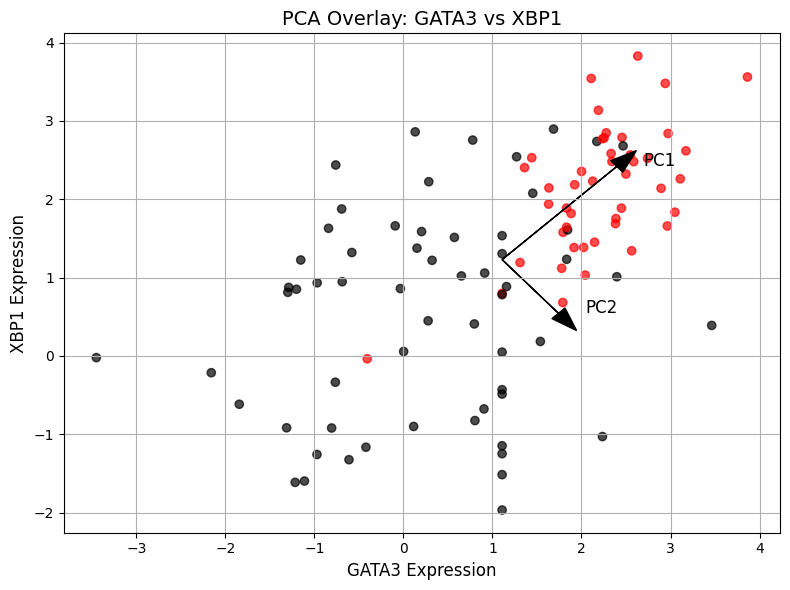

In [77]:
# --- PCA Analysis ---

# Function to run PCA manually
def custom_pca(matrix):
    centered = matrix - np.mean(matrix, axis=0)
    covariance = np.cov(centered, rowvar=False)
    eig_vals, eig_vecs = np.linalg.eigh(covariance)
    sorted_idx = np.argsort(eig_vals)[::-1]
    return eig_vecs[:, sorted_idx], eig_vals[sorted_idx], centered

# Combine data into a matrix (samples x features)
combined_matrix = np.column_stack((gata3_expr_values, xbp1_expr_values))

# Apply PCA
components, variances, centered_matrix = custom_pca(combined_matrix)
proj_primary = np.dot(centered_matrix, components[:, 0])
proj_secondary = np.dot(centered_matrix, components[:, 1])

# Align principal component direction
if np.mean(proj_primary[er_status == 1]) < np.mean(proj_primary[er_status == 0]):
    components[:, 0] *= -1
    proj_primary *= -1

# Compute vector origin (mean of each feature)
origin_gata3 = np.mean(gata3_expr_values)
origin_xbp1 = np.mean(xbp1_expr_values)

# Compute arrow scaling
scaler_pc1 = np.sqrt(variances[0])
scaler_pc2 = np.sqrt(variances[1])

# Plot PCA arrows on top of expression space
plt.figure(figsize=(8, 6))
plt.scatter(gata3_expr_values, xbp1_expr_values, c=color_assignments, alpha=0.7)
plt.arrow(origin_gata3, origin_xbp1, components[0, 0]*scaler_pc1, components[1, 0]*scaler_pc1,
          head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(origin_gata3, origin_xbp1, components[0, 1]*scaler_pc2, components[1, 1]*scaler_pc2,
          head_width=0.2, head_length=0.3, fc='black', ec='black')

plt.text(origin_gata3 + components[0, 0]*scaler_pc1 + 0.3,
         origin_xbp1 + components[1, 0]*scaler_pc1, 'PC1', fontsize=12)
plt.text(origin_gata3 + components[0, 1]*scaler_pc2 + 0.3,
         origin_xbp1 + components[1, 1]*scaler_pc2, 'PC2', fontsize=12)

plt.xlabel('GATA3 Expression', fontsize=12)
plt.ylabel('XBP1 Expression', fontsize=12)
plt.title('PCA Overlay: GATA3 vs XBP1', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


Generating 1c

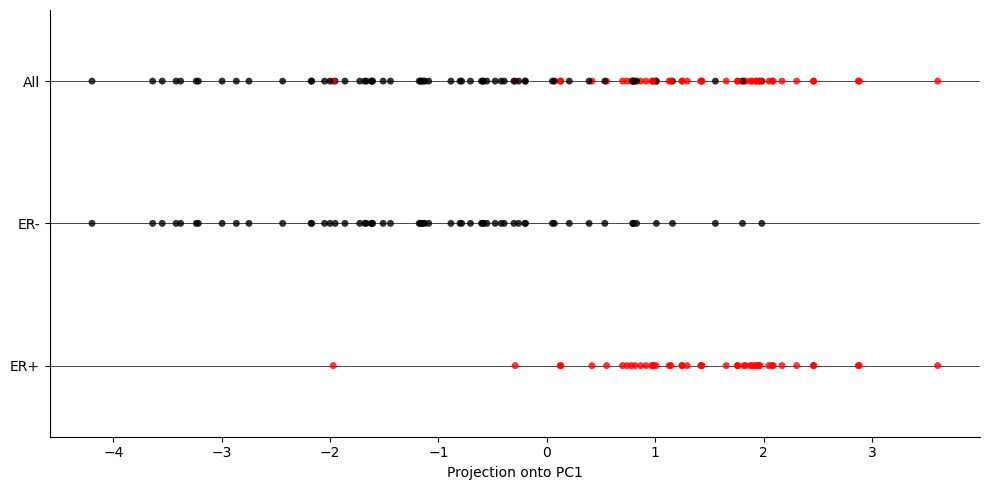

In [78]:
# DataFrame for ER+ samples
df_ER_positive = pd.DataFrame({
    "PC1": proj_primary[er_status == 1],
    "Group": "ER+",
    "Color": "red"
})

# Create DataFrame for all samples
df_ALL = pd.DataFrame({
    "PC1": proj_primary,
    "Group": "All",
    "Color": ["red" if status == 1 else "black" for status in er_status]
})

# DataFrame for ER- samples
df_ER_negative = pd.DataFrame({
    "PC1": proj_primary[er_status == 0],
    "Group": "ER-",
    "Color": "black"
})

# Combine all three for plotting
plot_data = pd.concat([df_ALL, df_ER_negative, df_ER_positive], ignore_index=True)

# Plot using seaborn
plt.figure(figsize=(10, 5))
Axis = sns.stripplot(
    data=plot_data,
    x="PC1", y="Group", hue="Color",
    palette={"red": "red", "black": "black"},
    dodge=False, jitter=False, alpha=0.8, size=5
)

# Aesthetic settings
Axis.yaxis.grid(True, linestyle='-', color='black', linewidth=0.5, alpha=1.0)
plt.xlabel("Projection onto PC1")
plt.ylabel("")
plt.legend([], [], frameon=False)
sns.despine()
plt.tight_layout()
plt.show()
